------
## Wstęp do Eksploracji Danych
### Laboratorium 13
------

### 0. Zadania rozgrzewkowe

### Zadanie 0.1
-----

a) Stwórz macierz M o wymiarach $4 \times 4$ zawierającą kolejne liczby parzyste zaczynając od 2.

b) Pomnóż wszystkie elementy w ostatnim wierszu tej macierzy przez 10.

c) Wyciągnij z macierzy M "podmacierz" o wymiarach $2 \times 2$, która znajduje się w samym centrum.

d) Znajdź indeksy wszystkich elementów w macierzy M, które są większe niż 20.

In [15]:
import numpy as np

In [16]:
# a)
M = np.arange(2, 34, 2).reshape(4,4)

In [17]:
M

array([[ 2,  4,  6,  8],
       [10, 12, 14, 16],
       [18, 20, 22, 24],
       [26, 28, 30, 32]])

In [18]:
# b)
M[3,:] *= 10

In [19]:
M

array([[  2,   4,   6,   8],
       [ 10,  12,  14,  16],
       [ 18,  20,  22,  24],
       [260, 280, 300, 320]])

In [20]:
# c)
M[1:3, 1:3]

array([[12, 14],
       [20, 22]])

In [ ]:
# d)
np.where(M > 20)

(array([2, 2, 3, 3, 3, 3], dtype=int64),
 array([2, 3, 0, 1, 2, 3], dtype=int64))

### Zadanie 0.2
-----
a) Wybierz tylko te gry, których `Ocena` jest wyższa niż 85.

b) Oblicz średnią sprzedaż (`Sprzedaż_MLN`) w podziale na `Gatunek`.

c) Posortuj ramkę danych według `Sprzedaż_MLN` malejąco.

d) Wyświetl tylko kolumny `Tytuł` i `Sprzedaż_MLN` dla co drugiego wiersza.

In [22]:
import pandas as pd
data = {
    'Tytuł': ['Cyberpunk 2077', 'The Witcher 3', 'Elden Ring', 'FIFA 23', 'Doom Eternal'],
    'Gatunek': ['RPG', 'RPG', 'RPG', 'Sport', 'Shooter'],
    'Sprzedaż_MLN': [20.1, 45.3, 20.5, 14.2, 10.8],
    'Ocena': [75, 92, 96, 70, 88]
}
nowe_gry = pd.DataFrame(data)

In [23]:
nowe_gry

,Tytuł,Gatunek,Sprzedaż_MLN,Ocena
0,Cyberpunk 2077,RPG,20.1,75
1,The Witcher 3,RPG,45.3,92
2,Elden Ring,RPG,20.5,96
3,FIFA 23,Sport,14.2,70
4,Doom Eternal,Shooter,10.8,88


In [24]:
# a)
nowe_gry.loc[nowe_gry.Ocena > 85]

,Tytuł,Gatunek,Sprzedaż_MLN,Ocena
1,The Witcher 3,RPG,45.3,92
2,Elden Ring,RPG,20.5,96
4,Doom Eternal,Shooter,10.8,88


In [ ]:
# b)
nowe_gry.groupby("Gatunek")["Sprzedaż_MLN"].\
    agg("mean").\
    to_frame().\
    reset_index().\
    rename(columns={'Sprzerdaż_MLN' : 'Średnia_sprzedaż_MLN'})

,Gatunek,Sprzedaż_MLN
0,RPG,28.633333
1,Shooter,10.800000
2,Sport,14.200000


In [31]:
# c)
nowe_gry.sort_values('Sprzedaż_MLN', ascending=False)

,Tytuł,Gatunek,Sprzedaż_MLN,Ocena
1,The Witcher 3,RPG,45.3,92
2,Elden Ring,RPG,20.5,96
0,Cyberpunk 2077,RPG,20.1,75
3,FIFA 23,Sport,14.2,70
4,Doom Eternal,Shooter,10.8,88


In [32]:
# d)
nowe_gry[["Tytuł", "Sprzedaż_MLN"]][::2]

,Tytuł,Sprzedaż_MLN
0,Cyberpunk 2077,20.1
2,Elden Ring,20.5
4,Doom Eternal,10.8


# 1. matplotlib

*Nicolas P. Rougier. Scientific Visualization: Python + Matplotlib. Nicolas P. Rougier. , 2021, https://inria.hal.science/hal-03427242/document*

**Figure** (Obiekt wykresu)

Główny element (kontener) tworzony funkcją figure. Pozwala na ustawienie rozmiaru, tytułu (`suptitle`) i koloru tła (`facecolor`).

*Ważne: Domyślne tło zapisu (`savefig`) jest białe i nadpisuje facecolor. Aby zapisać wykres bez tła, użyj `transparent=True`.*

**Axes (Układ współrzędnych / Podwykres)**

Obszar, na którym renderowane są dane (tzw. subplot). Figure może zawierać wiele obiektów Axes. Każdy z nich otoczony jest czterema krawędziami (spines), które domyślnie są ozdobione podziałkami (głównymi i pomocniczymi), ich etykietami oraz opisem osi (standardowo tylko lewa i dolna krawędź).

**Axis (Oś)**

Oznacza konkretną oś: poziomą (xaxis) lub pionową (yaxis). Składa się z linii krawędzi (spine), podziałek (ticks), etykiet podziałek oraz ogólnej etykiety osi.

**Spines (Krawędzie/Ramki)**

Linie wyznaczające granice obszaru danych i łączące punkty podziałki. Mogą być widoczne lub ukryte i znajdować się w dowolnym miejscu wykresu.

**Artist (Element graficzny)**
Wszystko, co widzisz na wykresie (Figure, Axes, Axis, teksty, linie, kształty), jest obiektem typu Artist. Podczas renderowania wszystkie te elementy są rysowane na płótnie (canvas). Dany obiekt Artist może należeć tylko do jednego układu Axes.

In [33]:
import matplotlib.pyplot as plt
import numpy as np

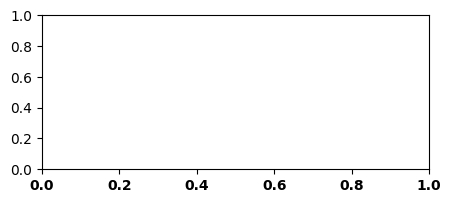

In [34]:
fig, ax = plt.subplots(figsize=(5,2))
for label in ax.get_xaxis().get_ticklabels():
    label.set_fontweight("bold")
plt.show()


## wykres liniowy 

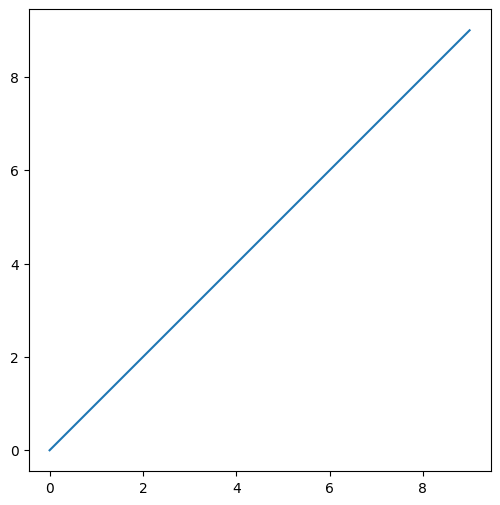

In [35]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(aspect=1)
ax.plot(range(10))
plt.show()

In [36]:
x = np.linspace(0, 2 * np.pi, 10)
y = np.sin(x)

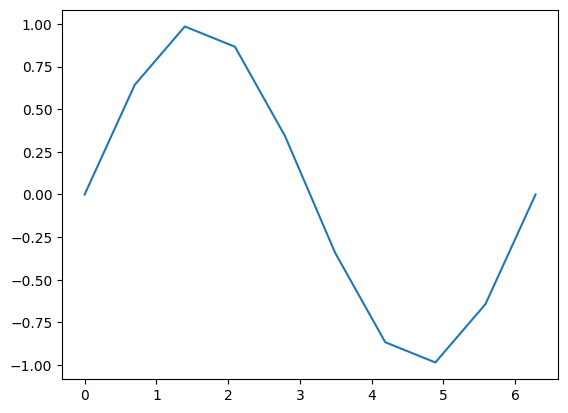

In [37]:
plt.plot(x, y)

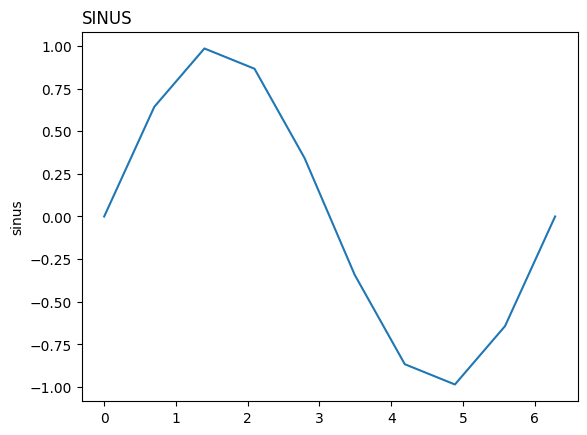

In [38]:
plt.plot(x, y)
plt.ylabel('sinus')
plt.title("SINUS", loc = "left")
plt.show()

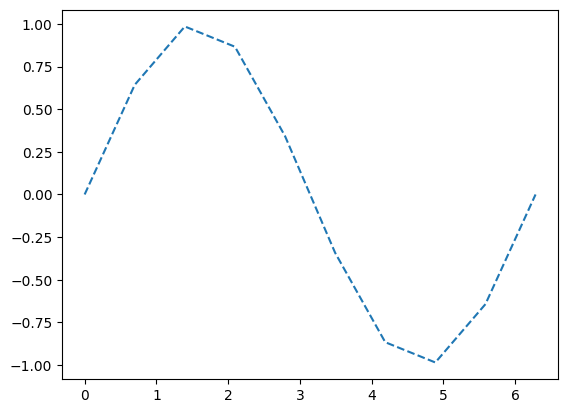

In [39]:
plt.plot(x, y, linestyle = "--")
plt.show()

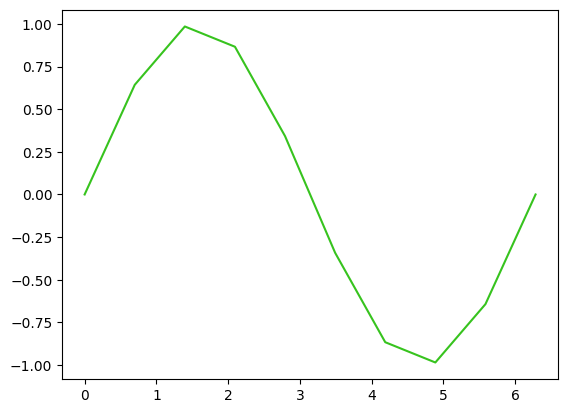

In [41]:
plt.plot(x, y, color = "#37c31e")

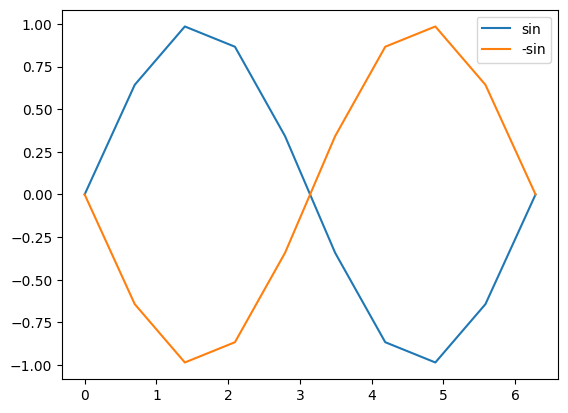

In [42]:
plt.plot(x, y, label = "sin")
plt.plot(x, -y, label = "-sin")
plt.legend()
plt.show()

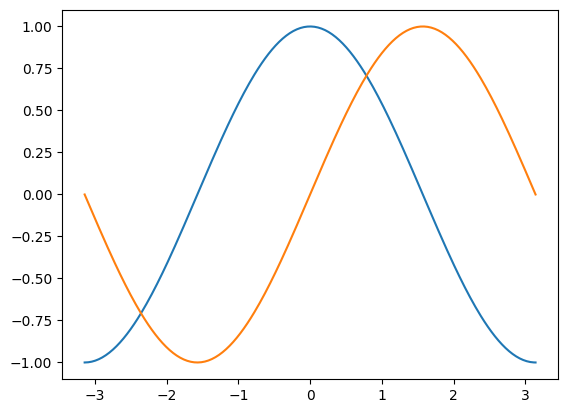

In [43]:
X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
C, S = np.cos(X), np.sin(X)
plt.plot(X, C)
plt.plot(X, S)
plt.show()

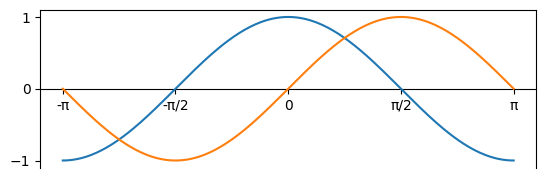

In [44]:
fig = plt.figure()
ax = plt.subplot(1,1,1,aspect=1)
ax.plot(X, C, markevery=(0, 64), clip_on=False, zorder=10)
ax.plot(X, S, markevery=(0, 64), clip_on=False, zorder=10)
ax.set_yticks([-1,0,1])
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(["-π", "-π/2", "0", "π/2", "π"])
ax.spines['bottom'].set_position(('data',0))

## wykres słupkowy

In [45]:
names  = ['A', 'B', 'C']
values = [2, 8, 15]

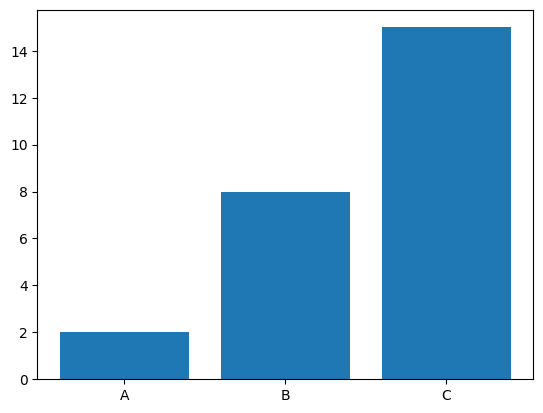

In [46]:
plt.bar(names, values)
plt.show()

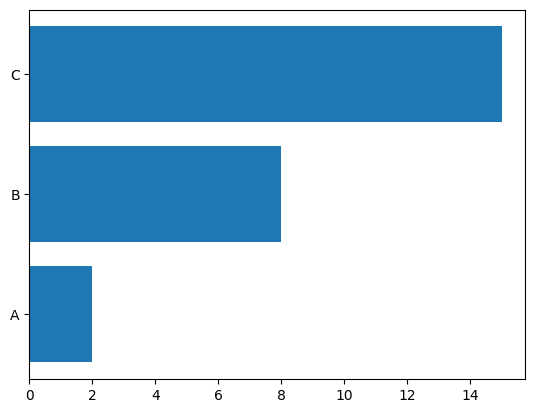

In [47]:
plt.barh(names, values)
plt.show()

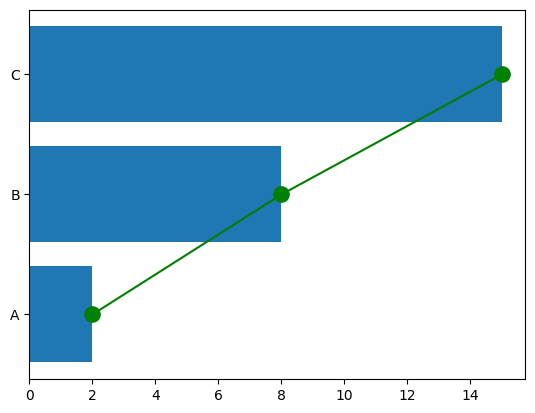

In [48]:
plt.barh(names, values)
plt.plot(values, names, color = "green", marker = ".", markersize = 22)
plt.show()

## wykres punktowy 

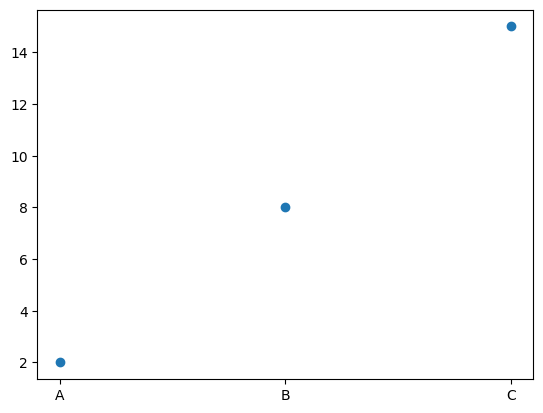

In [49]:
plt.scatter(names, values)
plt.show()

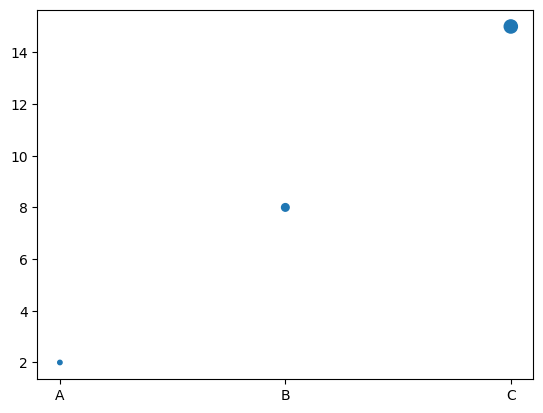

In [50]:
size = [10, 30, 90]
plt.scatter(names, values, s = size)
plt.show()

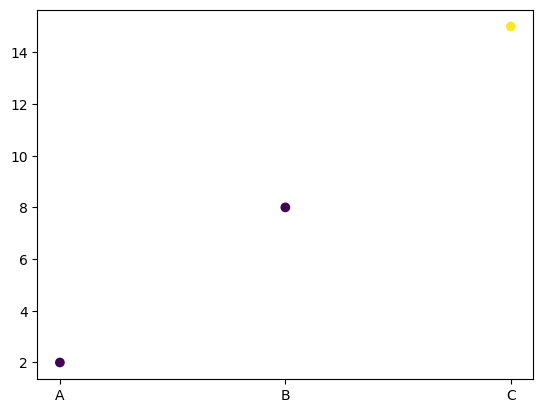

In [52]:
color = [2, 2, 4]
plt.scatter(names, values, c = color)
plt.show()

## histogram 

In [53]:
x = np.random.randn(1000)

num_bins = 50

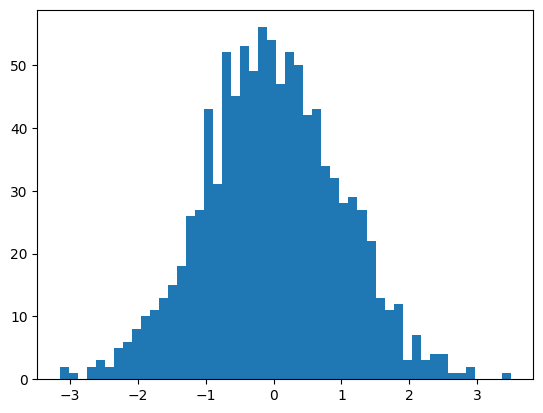

In [54]:
plt.hist(x, num_bins)
plt.show()

`plt.plot()` pozwala na narysowanie tylko jednej figury o współrzędnych (x,y)

In [55]:
names = ['X', 'Y', 'Z']
values = [3, 9, 27]

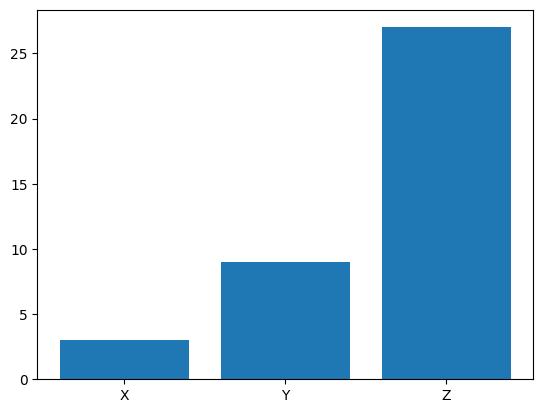

In [56]:
plt.bar(names, values)
plt.show()

`plt.figure()` definiuje figurę, możemy na niej umieszczać inne elementy

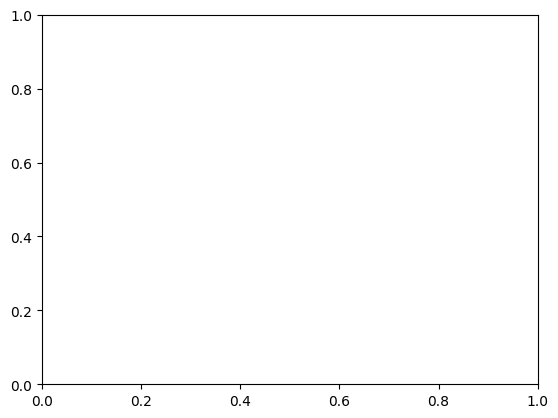

In [57]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1) #nrow, ncol, index
plt.show()

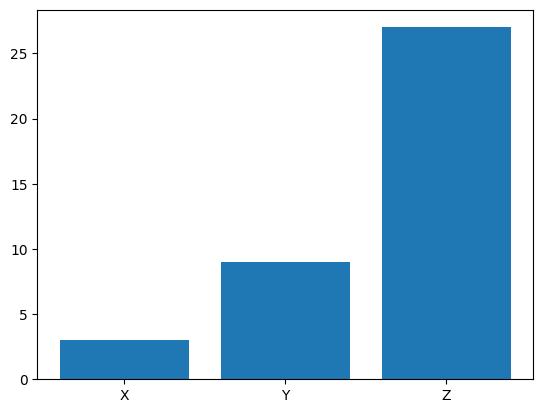

In [58]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1) #nrow, ncol, index
ax.bar(names, values)
plt.show()

`plt.subplot()` - pozwala na rysowanie jednej lub kilku figur w tym samym oknie

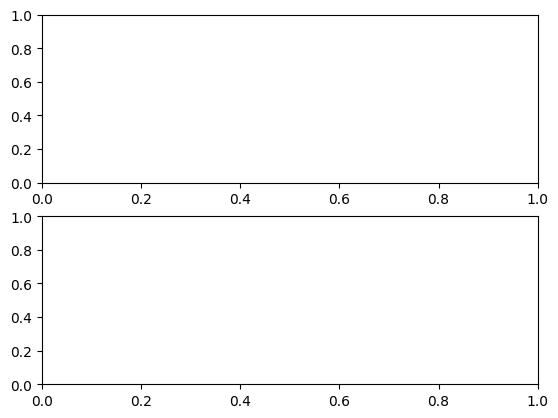

In [59]:
fig, (ax1, ax2) = plt.subplots(2, 1) #2 wiersze, 1 kolumna

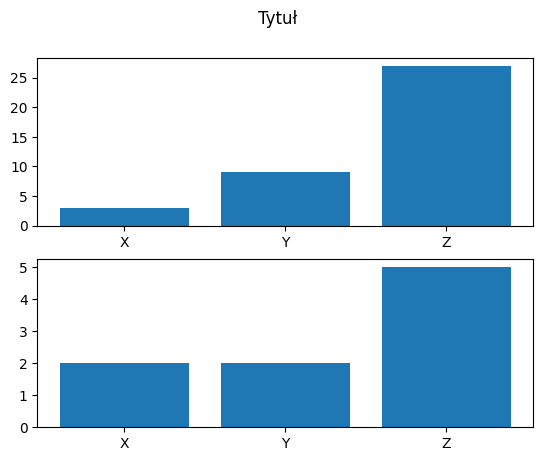

In [60]:
fig, (ax1, ax2) = plt.subplots(2, 1)
fig.suptitle('Tytuł')

ax1.bar(names, values)
ax2.bar(names, [2,2,5])

plt.show()

**Analiza zachowań klientów i przychodów sklepu internetowego z elektroniką**
------

Wyobraźmy sobie zbiór danych dotyczący zamówień w sklepie internetowym w ciągu ostatniego roku. Każdy rekord to jedno zamówienie.

Kolumny w zbiorze danych:

`Data` – data zakupu.

`Kategoria` – kategoria produktu (Smartfony, Laptopy, Akcesoria, Audio).

`Wiek_Klienta` – wiek osoby dokonującej zakupu.

`Wartosc_Zamowienia` – kwota w PLN.

`Typ_Urzadzenia` – urządzenie, na którym dokonano zakupu (Mobile, Desktop).

`Ocena_Produktu` – ocena wystawiona przez klienta (od 1 do 5).

In [61]:
df = pd.read_csv("dane_sprzedaz.csv")

In [62]:
df.head()

,Data,Kategoria,Wiek_Klienta,Wartosc_Zamowienia,Typ_Urzadzenia,Ocena_Produktu
0,2025-04-13,Akcesoria,57,167.700,Desktop,3
1,2025-12-15,Smartfony,20,2712.024,Mobile,5
2,2025-09-28,Laptopy,43,3412.630,Mobile,5
3,2025-04-17,Smartfony,18,1961.330,Mobile,5
4,2025-03-13,Smartfony,18,1976.150,Mobile,5


### Zadanie 1.1
-----

Sprawdź poniższą hipotezę.

*Sprzedaż ma charakter sezonowy, a największe przychody generowane są w okresie przedświątecznym*.

In [ ]:
# zmiana na format daty
df['Data'] = pd.to_datetime(df['Data'])

# wyciągniecie numeru miesiąca
df['Msc_num'] = df['Data'].dt.month

In [ ]:
# suma przychodów na miesiąc
przychody_msc = df.groupby('Msc_num')["Wartosc_Zamowienia"].sum()

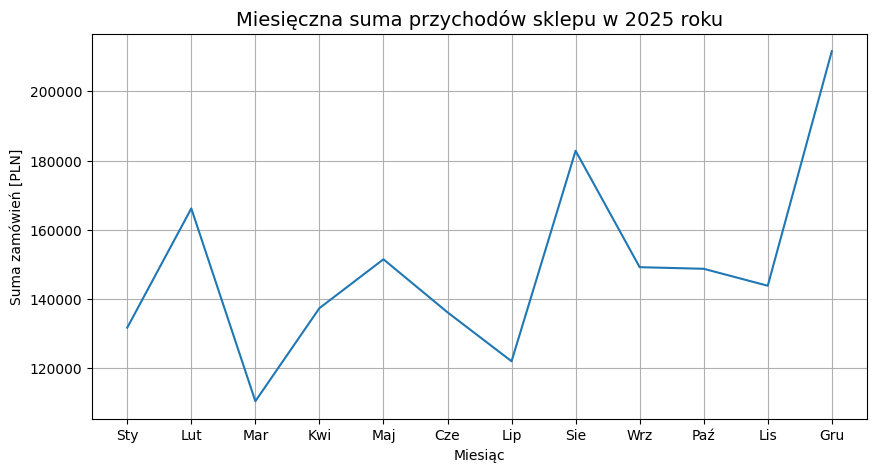

In [73]:
nazwy_miesiecy = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

plt.figure(figsize=(10,5))
plt.plot(nazwy_miesiecy, przychody_msc)

plt.title('Miesięczna suma przychodów sklepu w 2025 roku', fontsize = 14)
plt.xlabel("Miesiąc")
plt.ylabel("Suma zamówień [PLN]")
plt.grid(True)

### Zadanie 1.2
-----

Sprawdź poniższą hipotezę.

*Młodsi klienci kupują głównie Smartfony i Audio, podczas gdy starsi wolą Laptopy.*.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Data                1000 non-null   datetime64[ns]
 1   Kategoria           1000 non-null   object        
 2   Wiek_Klienta        1000 non-null   int64         
 3   Wartosc_Zamowienia  1000 non-null   float64       
 4   Typ_Urzadzenia      1000 non-null   object        
 5   Ocena_Produktu      1000 non-null   int64         
 6   Msc_num             1000 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(2)
memory usage: 50.9+ KB


In [81]:
kategorie = df.Kategoria.unique()

In [83]:
dane_wiek = [df[df['Kategoria'] == kat]["Wiek_Klienta"] for kat in kategorie]

C:\Users\AnnA\AppData\Local\Temp\ipykernel_41480\1800262004.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dane_wiek, labels = kategorie)


Text(0.5, 0, 'Kategorie produktów')

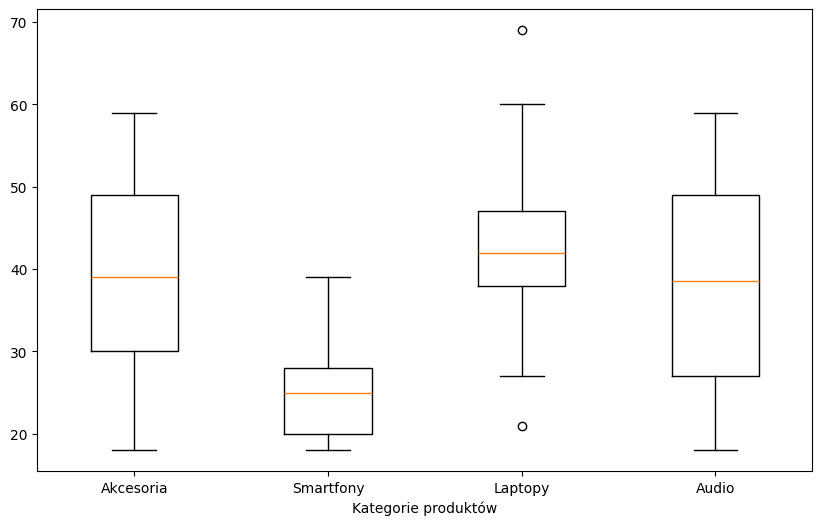

In [89]:
plt.figure(figsize=(10,6))
plt.boxplot(dane_wiek, labels = kategorie)
plt.xlabel("Kategorie produktów")

In [ ]:
# zakładamy, że młodsi klienci mają poniżej 30 lat
df1 = df.loc[df.Wiek_Klienta < 30]

In [99]:
df1.groupby("Kategoria")["Kategoria"].agg("count").to_frame().rename(columns={'Kategoria': 'Count'}).reset_index()

,Kategoria,Count
0,Akcesoria,85
1,Audio,50
2,Laptopy,2
3,Smartfony,240


In [100]:
df2 = df.loc[df.Wiek_Klienta >= 30]

In [101]:
df2.groupby("Kategoria")["Kategoria"].agg("count").to_frame().rename(columns={'Kategoria': 'Count'}).reset_index()

,Kategoria,Count
0,Akcesoria,265
1,Audio,110
2,Laptopy,186
3,Smartfony,62


### Zadanie 1.3
-----

Sprawdź poniższą hipotezę.

*Zakupy dokonywane na smartfonach (Mobile) mają mniejszą wartość, ale są lepiej oceniane przez użytkowników niż te na komputerach (Desktop).*.

In [102]:
srednie_dane = df.groupby('Typ_Urzadzenia').agg({
    'Wartosc_Zamowienia' : 'mean',
    'Ocena_Produktu': 'mean'
}).reset_index()

In [103]:
srednie_dane

,Typ_Urzadzenia,Wartosc_Zamowienia,Ocena_Produktu
0,Desktop,2121.538509,3.582716
1,Mobile,1565.920602,4.542857


Text(0.5, 1.0, 'Średnia ocena zadowolenia klienta')

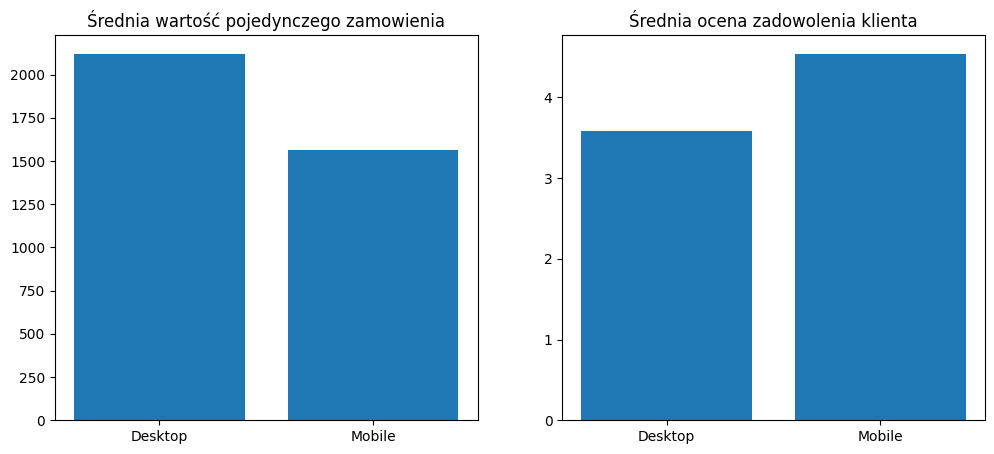

In [107]:
urzadzenia = srednie_dane['Typ_Urzadzenia']
srednia_wartosc = srednie_dane['Wartosc_Zamowienia']
srednia_ocena = srednie_dane['Ocena_Produktu']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1.bar(urzadzenia, srednia_wartosc)
ax1.set_title("Średnia wartość pojedynczego zamowienia")
ax2.bar(urzadzenia, srednia_ocena)
ax2.set_title("Średnia ocena zadowolenia klienta")

## `matplotlib` - poziom zaawansowany

## Konfiguracja `matplotlib`

**Jak dostosować właściwości i domyślny wygląd wykresów?**
- ustawiając `rcParams` (*runtime configuration parameters*),
- używając predefiniowanych stylów,
- tworząc/modyfikując plik `matplotlibrc` (*matplotlib runtime configuration*).

**Po co to robić?** 

- dla spójnego i jednolitego wyglądu wykresów:
    - w projekcie (raport, prezentacja, praca dyplomowa, ...),
    - w firmie (np. z wykorzystaniem szablonów, w zgodzie z identyfikacją wizualną);
- dla skrócenia czasu tworzenia wykresów i kodu potrzebnego do ich modyfikacji. 


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

### edytowanie `rcParams`

In [ ]:
mpl.rcParams # słownik z aktualnymi ustawieniami

In [ ]:
# domyślny wykres
np.random.seed(0)
data1 = np.random.normal(loc=-1, size=50)
data2 = np.random.normal(loc=1, size=50)

def example_plot():
    fig, axs = plt.subplots(1, 2)
    axs[0].plot(data1)
    axs[0].plot(data2)
    axs[1].hist(data1, alpha=0.5)
    axs[1].hist(data2, alpha=0.5)
    plt.show()

example_plot()

#### zmiana domyślnego rozmiaru wykresu i czcionki
(często przydatne do raportu lub prezentacji)

In [ ]:
print(mpl.rcParams["figure.figsize"])
print(mpl.rcParams["font.size"])

In [ ]:
mpl.rcParams["figure.figsize"] = (12, 6)
mpl.rcParams["font.size"] = 15

In [ ]:
example_plot()

#### zmiana sekwencji kolorów 

In [ ]:
mpl.rcParams["axes.prop_cycle"] # domyślny cykl kolorów

In [ ]:
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=["darkviolet", "forestgreen"]) # interesująca nas paleta kolorów

In [ ]:
# wykres z nowymi ustawieniami
example_plot()

#### zmiana stylu konkretnej grupy elementów 
np. linii, markerów, siatki, ...

In [ ]:
# linie
mpl.rcParams["lines.linewidth"] = 4
mpl.rcParams["lines.linestyle"] = "--"

# biny histogramu
mpl.rcParams["hist.bins"] = 6

# słupki (patch)
mpl.rcParams["patch.force_edgecolor"] = True  

# siatka na wykresie
mpl.rcParams["axes.grid"] = True  # żeby była siatka na wykresie
mpl.rcParams["axes.axisbelow"] = True  # żeby siatka była pod wykresem (domyślnie jest tylko pod liniami, ale nie pod punktami/słupkami)

In [ ]:
# wykres z nowymi ustawieniami
example_plot()

In [ ]:
# parametry w obrębie jednej grupy można też zmieniać tak:
mpl.rc("lines", linewidth=1, linestyle="-.")

In [ ]:
example_plot()

#### powrót do domyślnych ustawień

In [ ]:
plt.rcdefaults()

In [ ]:
example_plot()

### gotowe style
https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html

In [ ]:
print(plt.style.available)

In [ ]:
plt.style.use("ggplot")

In [ ]:
example_plot()

In [ ]:
plt.style.use("dark_background")

In [ ]:
example_plot()

In [ ]:
plt.rcdefaults()

## `matplotlib` - przydatne wskazówki

![](https://matplotlib.org/cheatsheets/_images/cheatsheets-1.png)

### złożone, dwuwymiarowe `subplots`
- spłaszczenie `axes` - `ax.flatten()`
- `plt.tight_layout()` w przypadku problemów z nachodzeniem się elementów
- `ax.set_facecolor()` w celu wyróżnienia jednego z wykresów

In [ ]:
mu = np.linspace(-4, 4, 9)
mu 

In [ ]:
# przed
fig, axs = plt.subplots(3, 3, figsize=(8, 6))
for i in range(3):
    for j in range(3):
        index = 3*i + j # :( 
        axs[i, j].hist(np.random.normal(loc=mu[index], size=1000), bins=30)
        axs[i, j].set_xlim(-7, 7)
        axs[i, j].set_title(f"mu = {mu[index]}")
plt.suptitle("Histogramy próbki z rozkładu normalnego o różnych średnich")
plt.show()

In [ ]:
# po
fig, axs = plt.subplots(3, 3, figsize=(8, 6))
axs = axs.flatten()  # żeby nie trzeba było odwoływać się do dwuwymiarowej tablicy
for i in range(len(axs)):
    axs[i].hist(np.random.normal(loc=mu[i], size=1000), bins=30)
    axs[i].set_xlim(-7, 7)
    axs[i].set_title(f"$\mu$ = {mu[i]}") # użycie TeXa
axs[4].set_facecolor("mistyrose")  # zmiana koloru tła
plt.suptitle("Histogramy próbki z rozkładu normalnego o różnych średnich")
plt.tight_layout()  # żeby się nie nakładały
plt.show()

### dodawanie anotacji, edycja podpisów osi, ... 

In [ ]:
x = np.linspace(0, 12 * np.pi, 1000)
y = np.sin(x)

In [ ]:
# podstawowy wykres
fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.plot(x, y, color="darkblue")
plt.show()

In [ ]:
# poprawiony wykres
fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.plot(x, y, color="darkblue")

# zacieniowanie obszaru, dodanie anotacji
ax.fill_betweenx([-1.1, 1.1], 0, 2 * np.pi, alpha=0.5, color="lightblue")
ax.text(np.pi / 2, -0.5, "okres", ha="center", va="center", color="darkblue")

# usunięcie białych marginesów przez zmianę granic osi
ax.set_xlim(0, 12 * np.pi)
ax.set_ylim(-1.1, 1.1)

# poprawa podpisów na osi x
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=np.pi))  # ustawienie podziałki co pi
ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda val, pos: f"${val / np.pi:.0f}\pi$")
)  # użycie TeXa do wyświetlania symbolu pi
# matplotlib.ticker.FuncFormatter -- funkcja powinna przyjmować wartość i pozycję, a zwracać stringa do wyświetlenia
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(n=2))  # podziałka co pi/2

plt.show()

### zapisywanie wykresów do pliku

**Przydatne argumenty:**
- `dpi` - dots per inch (rozdzielczość)
- `bbox_inches` - określa obszar, który ma być zapisany do pliku
- `transparent` - czy tło ma być przezroczyste


**O formatach:**
- Do raportów (w szczególności robionych w LaTeX-u) najlepiej zapisywać wykresy jako grafikę wektorową (np. `pdf` lub `svg`). Można wtedy wykorzystać np. Inkscape do dalszej edycji. 
- Jeśli konieczny jest format rastrowy, to lepiej użyć `png` niż `jpg` (lepsza jakość, wspiera przezroczystość).
- Do raportów w LaTeX-u można też użyć `pgf` (grafiki wektorowe z kodu) - wtedy wykresy są generowane przez LaTeX-a. Wymaga to zainstalowania dodatkowych pakietów, ale pozwala na zachowanie spójności czcionek i wyglądu wykresów z tekstem w dokumencie, a także na wykorzystanie na figurach LaTeX-owych poleceń (np. referencji do innego obiektu w dokumencie).

In [ ]:
fig

In [ ]:
fig.savefig("wykres1.png") 

In [ ]:
fig.savefig("wykres2.png", dpi=500, bbox_inches="tight") 

In [ ]:
fig.savefig("wykres3.png", dpi=500, bbox_inches="tight", transparent=True)

In [ ]:
fig.savefig("wykres.pgf", bbox_inches="tight") # zapis do PGF